# Non-ergodic Mess3 — analysis

Loads what `experiments/nonergodic/train.py` saved to its `run/` directory and
plots. All probe fitting goes through `src.metrics.probes`; experiment-specific
analysis is in `src.nonergodic.analysis`; plotting is in `plots.nonergodic`.

Sections: training curve · belief decodability · telescope geometry (2D + 3D) ·
component-identity probe · effective readout (start→end) · direct unembedding
inspection · causal-test stub.


In [2]:
import os, sys, json
import numpy as np
import matplotlib.pyplot as plt

# this notebook lives in plots/; repo root is one level up
REPO = os.path.abspath(os.path.join(os.getcwd(), ".."))
if REPO not in sys.path: sys.path.insert(0, REPO)

from src.nonergodic import analysis as A
from plots import nonergodic as P

RUN = os.path.join(REPO, "experiments", "nonergodic", "run")

cfg = json.load(open(os.path.join(RUN, "config.json")))
hmm = np.load(os.path.join(RUN, "hmm.npz"))
hist = np.load(os.path.join(RUN, "train_history.npz"))
val = np.load(os.path.join(RUN, "val_data.npz"))
gt = np.load(os.path.join(RUN, "ground_truth.npz"))
act = np.load(os.path.join(RUN, "activations.npz"))
wts = np.load(os.path.join(RUN, "weights.npz"))

K = len(cfg["comp_params"]); S = cfg["n_states"]; V = cfg["vocab"]; L = cfg["seq_len"]
d = cfg["d_model"]
M_block = hmm["M_block"]; comp_params = hmm["comp_params"]
print("components:", comp_params.tolist())


components: [[0.05, 0.05], [0.9, 0.15]]


## 1. Training curve

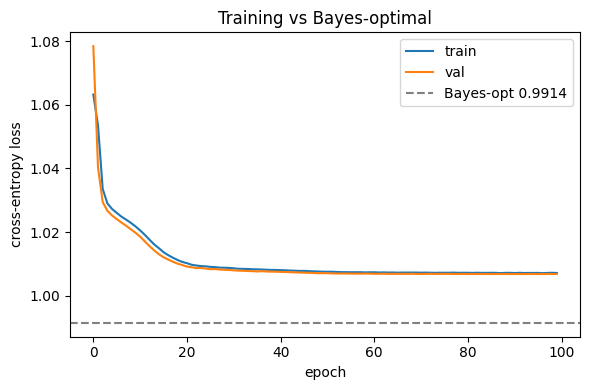

In [12]:
P.plot_training_curve(hist["train_loss"], hist["val_loss"], float(hist["opt_loss"]))
plt.tight_layout(); plt.show()

## 2. Telescoped-belief decodability  (via src.metrics.probes)

per-component test R²: {0: 0.406, 1: 0.495}


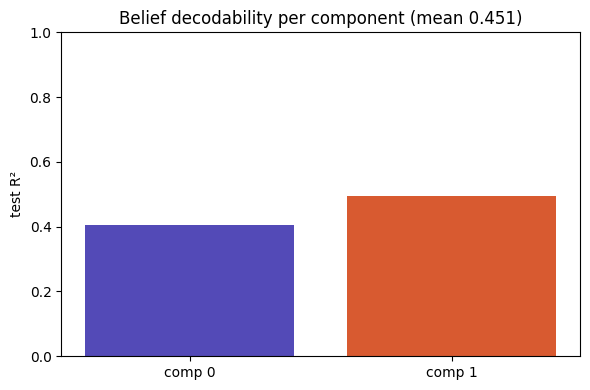

In [13]:
resid = act["resid_final"].reshape(-1, d)
B = gt["telescoped"].reshape(-1, K*S)
probe = A.decode_beliefs(resid, B, S, seed=0)
print("per-component test R²:", {c: round(r,3) for c,r in probe["per_block_r2"].items()})
P.plot_belief_r2(probe["per_block_r2"]); plt.tight_layout(); plt.show()

## 3. Telescope geometry

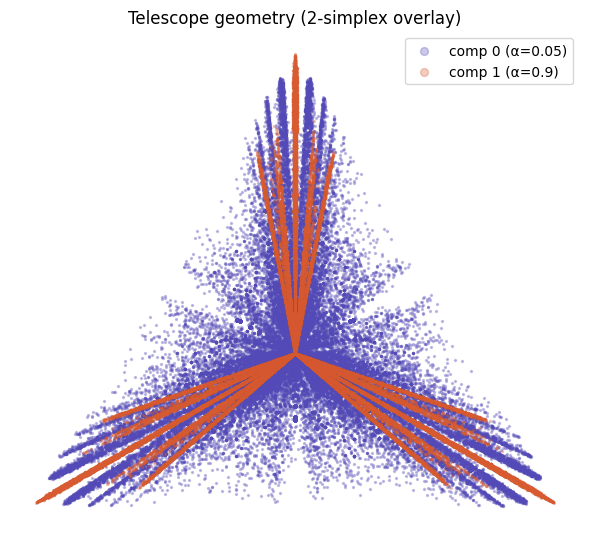

In [5]:
tel = gt["telescoped"].reshape(-1, K*S)
P.plot_telescope_2d(A.telescope_2d(tel, S), comp_params); plt.tight_layout(); plt.show()

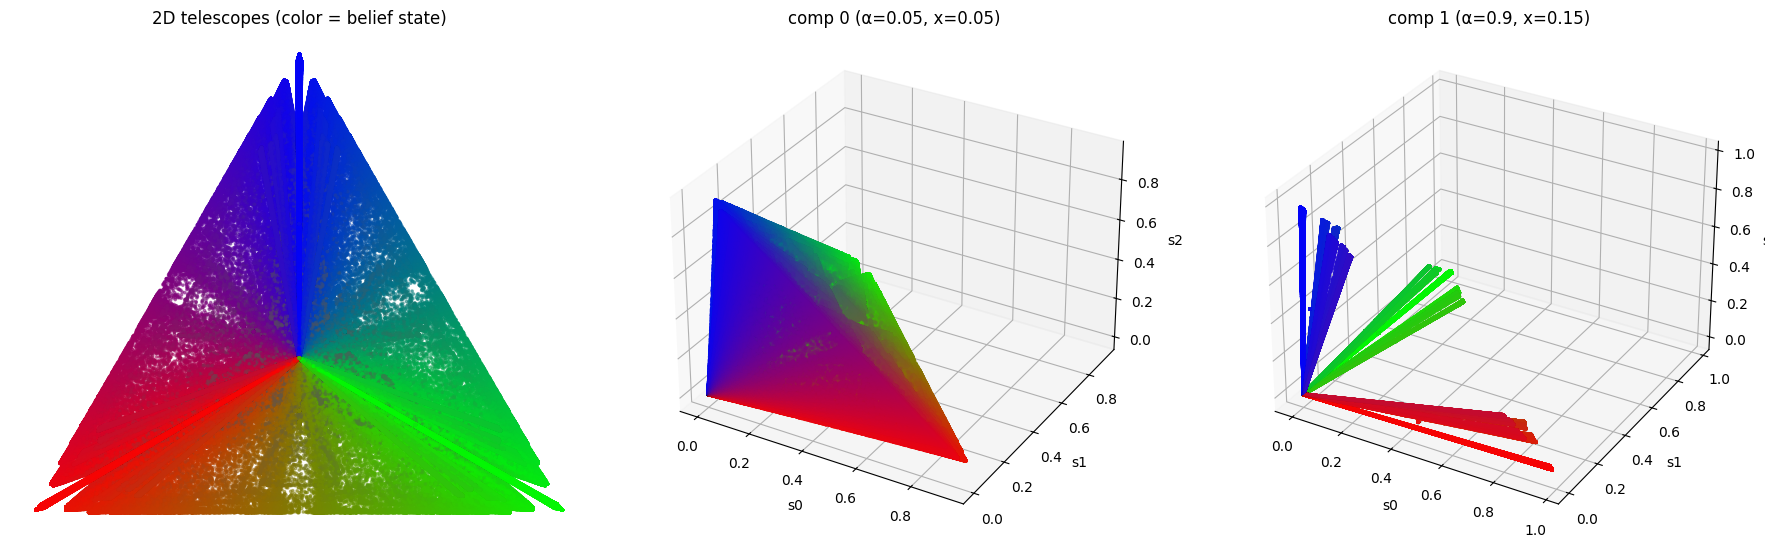

In [14]:
# Telescope geometry colored by belief state (RGB = simplex coords)
tel = gt["telescoped"].reshape(-1, K*S)

verts = np.array([[0,0],[1,0],[0.5,0.8660254]]); cen = verts.mean(0)

fig = plt.figure(figsize=(6*(K+1), 5.5))

# --- 2D overlay (all components on one simplex) ---
ax = fig.add_subplot(1, K+1, 1)
for n in range(K):
    blk = tel[:, n*S:(n+1)*S]
    w = blk.sum(1, keepdims=True)
    eta = np.divide(blk, w, out=np.zeros_like(blk), where=w>1e-9)
    xy = eta @ verts
    pts = cen + (xy - cen) * w                 # scale toward center by weight
    ax.scatter(pts[:,0], pts[:,1], s=3, c=np.clip(eta,0,1), alpha=0.5)
ax.set_aspect("equal"); ax.axis("off")
ax.set_title("2D telescopes (color = belief state)")

# --- 3D, one panel per component ---
for n in range(K):
    ax = fig.add_subplot(1, K+1, n+2, projection="3d")
    blk = tel[:, n*S:(n+1)*S]
    w = blk.sum(1, keepdims=True)
    eta = np.divide(blk, w, out=np.zeros_like(blk), where=w>1e-9)
    ax.scatter(blk[:,0], blk[:,1], blk[:,2], s=3, c=np.clip(eta,0,1), alpha=0.5)
    ax.set_title(f"comp {n} (α={comp_params[n][0]}, x={comp_params[n][1]})")
    ax.set_xlabel("s0"); ax.set_ylabel("s1"); ax.set_zlabel("s2")

plt.tight_layout(); plt.show()

## 4. Component-identity probe across positions  (via src.metrics.probes)

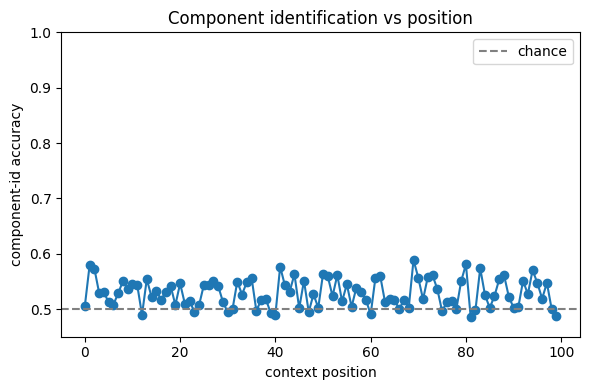

In [15]:
acc = A.component_probe_by_position(act["resid_final"], val["val_comps"], seed=0)
P.plot_component_probe(acc); plt.tight_layout(); plt.show()

## 5. Effective readout (start→end)

Fit (shared probe code) decoded belief -> model probs, column-center to remove
the sum-to-1 gauge, compare to the true block emission. This is the start→end
argument: shows the implied map is emission-shaped, not that the unembedding
mechanism implements it.

cosine(recovered, true block emission), centered: 1.0


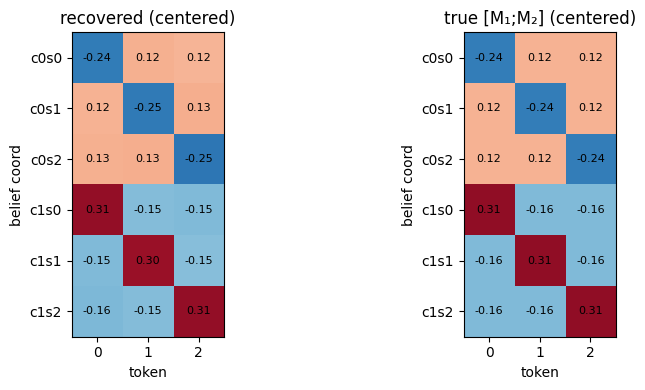

In [16]:
Pm = act["model_probs"].reshape(-1, V)
M_rec, M_rec_c = A.recover_readout(probe["decoded_all"], Pm)
print("cosine(recovered, true block emission), centered:",
      round(A.cosine(M_rec_c, A.col_center(M_block)), 3))
P.plot_readout_recovery(M_rec_c, A.col_center(M_block), S); plt.show()

## 6. Direct unembedding inspection

`logits = resid_final @ W_U`. Pull `W_U` back into belief coordinates: how much
of it lives in the belief subspace, and does its belief-relevant action match
the (log) emission matrix.

captured energy in belief subspace: 0.507 (random ~ 0.047, clean = 1.0)
reconstruction rel error          : 0.702
cosine(pullback, log-emission)    : 0.960
cosine(pullback, emission)        : 0.913


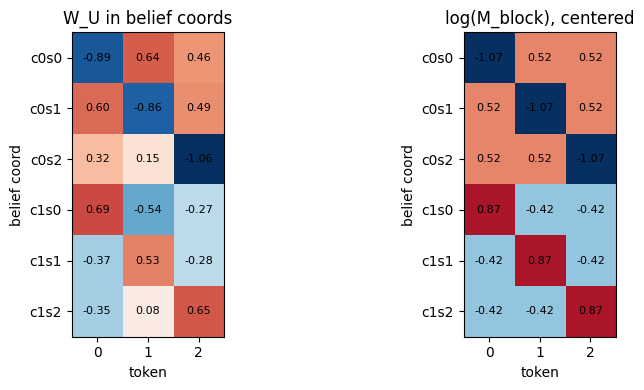

In [17]:
W_U = wts["W_U"].T
insp = A.inspect_unembedding(W_U, probe["W"], M_block)
print(f"captured energy in belief subspace: {insp['captured_energy']:.3f} "
      f"(random ~ {insp['random_baseline']:.3f}, clean = 1.0)")
print(f"reconstruction rel error          : {insp['recon_rel_err']:.3f}")
print(f"cosine(pullback, log-emission)    : {insp['cos_logM']:.3f}")
print(f"cosine(pullback, emission)        : {insp['cos_M']:.3f}")
P.plot_unembedding_inspection(insp["pullback_centered"], insp["logM_centered"], S); plt.show()

In [3]:
# Emission readout in PROBABILITY space (Option B) + Kyle's log-vs-linear check
from scipy.special import softmax  # or: def softmax(z,axis=-1): e=np.exp(z-z.max(axis,keepdims=True)); return e/e.sum(axis,keepdims=True)

resid = act["resid_final"].reshape(-1, d)
B = gt["telescoped"].reshape(-1, K*S)
probe = A.decode_beliefs(resid, B, S, seed=0)
P = probe["W"][:-1]                       # (d, K*S)
bhat = probe["decoded_all"]               # (N, K*S) decoded belief
Wu = wts["W_U"].T                         # (d, V)

# pullback in logit space
E = np.linalg.lstsq(P, Wu, rcond=None)[0] # (K*S, V)

# --- Option B: compare in probability space, where p = b·M is exact ---
pred_theory   = bhat @ M_block            # (N, V) theory probs (already normalized)
pred_theory  /= pred_theory.sum(1, keepdims=True)
pred_pullback = softmax(bhat @ E, axis=1) # (N, V) model readout pushed through softmax
model_probs   = act["model_probs"].reshape(-1, V)

def r2(y, yhat): 
    return 1 - ((y-yhat)**2).sum() / ((y-y.mean(0))**2).sum()

print("PROBABILITY-SPACE comparison (where p = b·M is exact):")
print(f"  R²(pullback-readout vs theory  b·M): {r2(pred_theory, pred_pullback):.4f}")
print(f"  R²(actual model probs vs theory b·M): {r2(pred_theory, model_probs):.4f}")
print(f"  mean |pullback - theory| per prob:   {np.abs(pred_pullback-pred_theory).mean():.4f}")

# --- Kyle #2: is log(p) ~ p degenerate for these emission matrices? ---
print("\nKyle #2 — log-vs-linear degeneracy of the emission matrix:")
for n in range(K):
    Mn = M_block[n*S:(n+1)*S]
    vals = np.unique(np.round(Mn.ravel(), 6))
    p = Mn.ravel(); lp = np.log(p)
    A_ = np.vstack([p, np.ones_like(p)]).T
    coef = np.linalg.lstsq(A_, lp, rcond=None)[0]
    r2_loglin = 1 - ((lp - A_@coef)**2).sum() / ((lp - lp.mean())**2).sum()
    print(f"  comp {n}: {len(vals)} distinct emission values {np.round(vals,3)}, "
          f"log(p)~p linear R²={r2_loglin:.4f}")
print("  NOTE: Mess3's symmetric emission has only 2 distinct values per matrix,")
print("  so log(p) vs p is trivially linear (2 points = a line). This is exactly")
print("  Kyle's concern: for these params, matching log(M) and matching M are")
print("  nearly the same test, so a high cosine doesn't isolate the log structure.")

PROBABILITY-SPACE comparison (where p = b·M is exact):
  R²(pullback-readout vs theory  b·M): -10.9212
  R²(actual model probs vs theory b·M): 0.9936
  mean |pullback - theory| per prob:   0.4448

Kyle #2 — log-vs-linear degeneracy of the emission matrix:
  comp 0: 2 distinct emission values [0.092 0.454], log(p)~p linear R²=1.0000
  comp 1: 2 distinct emission values [0.178 0.645], log(p)~p linear R²=1.0000
  NOTE: Mess3's symmetric emission has only 2 distinct values per matrix,
  so log(p) vs p is trivially linear (2 points = a line). This is exactly
  Kyle's concern: for these params, matching log(M) and matching M are
  nearly the same test, so a high cosine doesn't isolate the log structure.


In [5]:
def softmax(z, axis=-1):
    e = np.exp(z - z.max(axis, keepdims=True)); return e/e.sum(axis, keepdims=True)

resid = act["resid_final"].reshape(-1, d)
B = gt["telescoped"].reshape(-1, K*S)
probe = A.decode_beliefs(resid, B, S, seed=0)
bhat = probe["decoded_all"]                          # (N,6)

# model's actual logits (recompute: logits = resid @ Wu)
Wu = wts["W_U"].T
logits_model = resid @ Wu                            # (N,3)
p_model = softmax(logits_model, 1)
p_truth = B @ M_block; p_truth /= p_truth.sum(1, keepdims=True)

# fit belief -> model logits WITH bias, then softmax
Xb = np.hstack([bhat, np.ones((len(bhat),1))])
W_bl, *_ = np.linalg.lstsq(Xb, logits_model, rcond=None)   # (7,3)
logits_readout = Xb @ W_bl
p_readout = softmax(logits_readout, 1)

def r2(y,yh): return 1 - ((y-yh)**2).sum()/((y-y.mean(0))**2).sum()
def kl(p,q,e=1e-9): p=np.clip(p,e,1);q=np.clip(q,e,1); return float((p*np.log(p/q)).sum(1).mean())

print("belief-readout vs MODEL :", f"R²={r2(p_model,p_readout):.4f}  KL={kl(p_model,p_readout):.4f}")
print("belief-readout vs TRUTH :", f"R²={r2(p_truth,p_readout):.4f}  KL={kl(p_truth,p_readout):.4f}")
print("model        vs TRUTH  :", f"R²={r2(p_truth,p_model):.4f}  KL={kl(p_truth,p_model):.4f}")
print("readout linear weights (belief->logits), bias last row:\n", np.round(W_bl,3))

belief-readout vs MODEL : R²=0.9961  KL=0.0004
belief-readout vs TRUTH : R²=0.8549  KL=0.0153
model        vs TRUTH  : R²=0.8519  KL=0.0156
readout linear weights (belief->logits), bias last row:
 [[ 1069933.392   118222.639   630537.823]
 [ 1069935.544   118221.59    630538.39 ]
 [ 1069934.882   118222.531   630536.12 ]
 [ 1069936.575   118223.147   630538.34 ]
 [ 1069934.919   118223.641   630537.778]
 [ 1069934.945   118222.609   630538.887]
 [-1069936.705  -118224.354  -630539.544]]


In [6]:
def softmax(z, axis=-1):
    e = np.exp(z - z.max(axis, keepdims=True)); return e/e.sum(axis, keepdims=True)

resid = act["resid_final"].reshape(-1, d)
B = gt["telescoped"].reshape(-1, K*S)
probe = A.decode_beliefs(resid, B, S, seed=0)
P = probe["W"][:-1]
Wu = wts["W_U"].T
E = np.linalg.lstsq(P, Wu, rcond=None)[0]      # (K*S, V) pullback in logit space

E_sm = softmax(E, axis=1)                       # softmax each row -> predicted emission
print("softmax(E)  (predicted emission per hidden state):")
print(np.round(E_sm, 3))
print("\nM_block  (true emission):")
print(np.round(M_block, 3))
print("\nper-row KL(M || softmax(E)):")
for i in range(K*S):
    p, q = M_block[i], E_sm[i]
    print(f"  row {i}: {(p*np.log(np.clip(p,1e-9,1)/np.clip(q,1e-9,1))).sum():.4f}")

softmax(E)  (predicted emission per hidden state):
[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]

M_block  (true emission):
[[0.092 0.454 0.454]
 [0.454 0.092 0.454]
 [0.454 0.454 0.092]
 [0.645 0.178 0.178]
 [0.178 0.645 0.178]
 [0.178 0.178 0.645]]

per-row KL(M || softmax(E)):
  row 0: 10.3828
  row 1: 10.3828
  row 2: 17.8690
  row 3: 16.1483
  row 4: 16.1483
  row 5: 6.4602


In [8]:
val = np.load("../experiments/nonergodic/run/val_data.npz")
seqs, comps = val["val_seqs"], val["val_comps"]
print("tokens used by comp 0:", np.unique(seqs[comps==0]))
print("tokens used by comp 1:", np.unique(seqs[comps==1]))

tokens used by comp 0: [0 1 2]
tokens used by comp 1: [0 1 2]


In [10]:
P.shape

(128, 6)

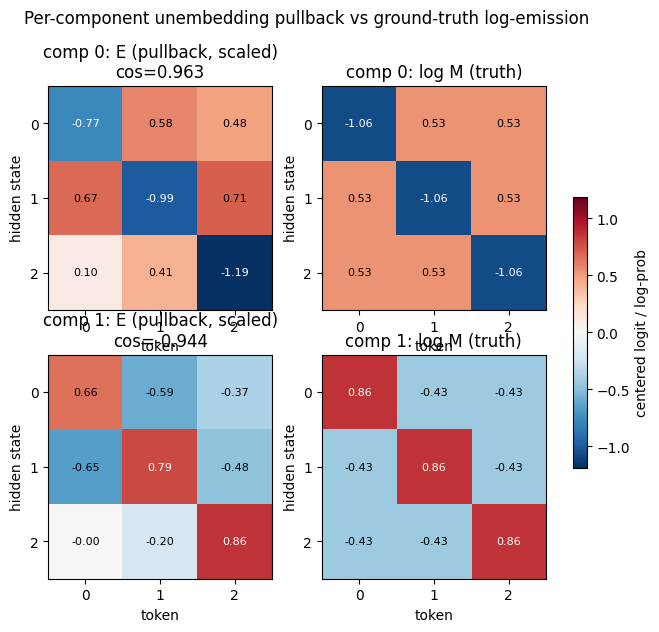

In [12]:
import numpy as np
import matplotlib.pyplot as plt

resid = act["resid_final"].reshape(-1, d)
B = gt["telescoped"].reshape(-1, K*S)
Wu = wts["W_U"].T

def fit_probe(X, Y, ridge=1e-4):
    Xb = np.hstack([X, np.ones((len(X),1))])
    return np.linalg.solve(Xb.T@Xb + ridge*np.eye(Xb.shape[1]), Xb.T@Y)
def col_center(M): return M - M.mean(0, keepdims=True)
def cosine(a,b): a,b=a.ravel(),b.ravel(); return float(a@b/(np.linalg.norm(a)*np.linalg.norm(b)))

# per-component pullbacks (centered) and centered log-emissions
Es, logMs, coss = [], [], []
for n in range(K):
    Pn = fit_probe(resid, B[:, n*S:(n+1)*S])[:-1]      # (d,3)
    En = np.linalg.lstsq(Pn, Wu, rcond=None)[0]        # (3,3)
    Mn = M_block[n*S:(n+1)*S]
    logMn = np.log(np.clip(Mn, 1e-6, None))
    Ec, Lc = col_center(En), col_center(logMn)
    # align sign/scale of E to logM for visual comparability (cosine is scale-free)
    s = (Ec.ravel() @ Lc.ravel()) / (Ec.ravel() @ Ec.ravel())
    Es.append(s * Ec); logMs.append(Lc); coss.append(cosine(Ec, Lc))

# shared color scale
vmax = max(np.abs(np.concatenate(Es)).max(), np.abs(np.concatenate(logMs)).max())

fig, axes = plt.subplots(K, 2, figsize=(7, 3.2*K))
if K == 1: axes = axes[None, :]
for n in range(K):
    for col, (M, title) in enumerate([(Es[n], f"comp {n}: E (pullback, scaled)"),
                                       (logMs[n], f"comp {n}: log M (truth)")]):
        ax = axes[n, col]
        im = ax.imshow(M, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        ax.set_xticks(range(S)); ax.set_yticks(range(S))
        ax.set_xlabel("token"); ax.set_ylabel("hidden state")
        ax.set_title(title + (f"\ncos={coss[n]:.3f}" if col==0 else ""))
        for i in range(S):
            for j in range(S):
                ax.text(j, i, f"{M[i,j]:.2f}", ha="center", va="center",
                        fontsize=8, color="black" if abs(M[i,j])<vmax*0.6 else "white")
fig.colorbar(im, ax=axes, fraction=0.025, label="centered logit / log-prob")
plt.suptitle("Per-component unembedding pullback vs ground-truth log-emission", y=1.0)
plt.show()

In [13]:
import numpy as np
from src.nonergodic import analysis as A

B = gt["telescoped"].reshape(-1, K*S)

stages = [
    ("resid_pre  (embedding)",      "embedding"),
    ("resid_mid  (post-attn)",      "resid_post_attn"),
    ("resid_post (post-mlp)",       "resid_post_mlp"),
    ("resid_final(post-LN→unembed)","resid_final"),
]

print(f"{'stage':<32} {'mean R²':>8}   per-component")
rows = []
for label, key in stages:
    resid = act[key].reshape(-1, act[key].shape[-1])
    probe = A.decode_beliefs(resid, B, S, seed=0)
    per = probe["per_block_r2"]                      # {comp: R²}
    mean = np.mean(list(per.values()))
    rows.append((label, mean, per))
    print(f"{label:<32} {mean:>8.3f}   " +
          "  ".join(f"c{c}={per[c]:.3f}" for c in sorted(per)))

stage                             mean R²   per-component
resid_pre  (embedding)              0.305   c0=0.151  c1=0.459
resid_mid  (post-attn)              0.389   c0=0.298  c1=0.480
resid_post (post-mlp)               0.450   c0=0.405  c1=0.494
resid_final(post-LN→unembed)        0.451   c0=0.406  c1=0.495


In [14]:
import numpy as np

resid = act["resid_final"].reshape(-1, d)
B = gt["telescoped"].reshape(-1, K*S)

def fit_probe(X, Y, ridge=1e-4):
    Xb = np.hstack([X, np.ones((len(X),1))])
    return np.linalg.solve(Xb.T@Xb + ridge*np.eye(Xb.shape[1]), Xb.T@Y)

# per-component probes: each (d, 3) after dropping bias
P0 = fit_probe(resid, B[:, 0*S:1*S])[:-1]     # comp 0 belief directions
P1 = fit_probe(resid, B[:, 1*S:2*S])[:-1]     # comp 1 belief directions

# --- principal angles between the two 3-dim subspaces ---
Q0, _ = np.linalg.qr(P0)                       # orthonormal basis, (d, 3)
Q1, _ = np.linalg.qr(P1)
sv = np.linalg.svd(Q0.T @ Q1, compute_uv=False)   # singular values = cos(principal angles)
angles_deg = np.degrees(np.arccos(np.clip(sv, -1, 1)))

print("cos(principal angles):", np.round(sv, 3))
print("principal angles (deg):", np.round(angles_deg, 1))
print("  1.0 / 0°  = subspaces share that direction exactly")
print("  0.0 / 90° = orthogonal in that direction")

# summary scalars
overlap = (sv**2).mean()        # avg squared cosine: 1 = identical subspaces, 0 = orthogonal
print(f"\nmean squared cosine (subspace overlap): {overlap:.3f}")
print(f"  random 3-dim subspaces in {d}-dim space would give ~ {3/d:.3f}")

# --- raw column cosines too (basis-dependent, but interpretable per coordinate) ---
def colnorm(M): return M / np.linalg.norm(M, axis=0, keepdims=True)
C = colnorm(P0).T @ colnorm(P1)               # (3,3): cos between P0 col i and P1 col j
print("\npairwise column cosines (rows = comp0 states, cols = comp1 states):")
print(np.round(C, 3))

cos(principal angles): [1.    0.88  0.781]
principal angles (deg): [ 0.6 28.3 38.6]
  1.0 / 0°  = subspaces share that direction exactly
  0.0 / 90° = orthogonal in that direction

mean squared cosine (subspace overlap): 0.795
  random 3-dim subspaces in 128-dim space would give ~ 0.023

pairwise column cosines (rows = comp0 states, cols = comp1 states):
[[ 0.452 -0.64  -0.53 ]
 [-0.602  0.359 -0.301]
 [-0.648 -0.56   0.424]]


In [17]:
np.array([ 0.6, 28.3, 38.6]).mean()

np.float64(22.5)

In [18]:
import numpy as np

resid = act["resid_final"].reshape(-1, d)
B = gt["telescoped"].reshape(-1, K*S)

def fit_probe(X, Y, ridge=1e-4):
    Xb = np.hstack([X, np.ones((len(X),1))])
    return np.linalg.solve(Xb.T@Xb + ridge*np.eye(Xb.shape[1]), Xb.T@Y)

W_joint = fit_probe(resid, B)                       # (d+1, 6)
W0 = fit_probe(resid, B[:, :S])                     # (d+1, 3)
W1 = fit_probe(resid, B[:, S:])                     # (d+1, 3)
W_concat = np.hstack([W0, W1])                      # (d+1, 6)

diff = np.abs(W_joint - W_concat)
print("max |joint - concat|:", diff.max())
print("relative Frobenius  :", np.linalg.norm(W_joint - W_concat) / np.linalg.norm(W_joint))
print("identical to float tolerance:", np.allclose(W_joint, W_concat, atol=1e-8))

max |joint - concat|: 4.896808326881885e-09
relative Frobenius  : 3.844725107617229e-08
identical to float tolerance: True
